# Beyond Binary: Four-Class Risk Stratification from Gastrointestinal Endoscopy Using Asymmetric-Cost CNN-Transformer Learning and Demographic Equity Analysis
## DenseNet-121 · EfficientNet-B4 · ViT-B/16 · Swin-T | Asymmetric Endoscopy Loss | GradCAM | MC Dropout | CD-CTEI

**Author:** Azizur Rahman
**Affiliation:** Indiana Wesleyan University · RadTH Technologies
**Target Venue:** Computers in Biology and Medicine

---
### Notebook Contents
| # | Section |
|---|---------|
| 1 | Environment Setup |
| 2 | Dataset Loading & 4-Class Label Mapping |
| 3 | Data Augmentation & DataLoader |
| 4 | Model Architecture (DenseNet-121, EfficientNet-B4, ViT-B/16, Swin-T) |
| 5 | Asymmetric Endoscopy Loss (AEL) |
| 6 | Training with Transfer Learning |
| 7 | AEL Ablation Study |
| 8 | Cross-Dataset Evaluation (Kvasir-v2) |
| 9 | ROC-AUC Curves |
| 10 | GradCAM Explainability |
| 11 | Monte Carlo Dropout Uncertainty |
| 12 | Endoscopist Workload Simulation |
| 13 | Cross-Demographic Equity (CD-CTEI) |
| 14 | Results Summary & Paper Tables |

---
### 4-Class Clinical Risk Stratification Schema (ACG/ESGE Guideline-Aligned)
| Class | Label | HyperKvasir Sources | Clinical Action |
|---|---|---|---|
| 0 | Normal | normal-cecum, normal-pylorus, normal-z-line, retroflex-stomach, retroflex-rectum, ileum, bbps-2-3 | Routine surveillance interval |
| 1 | Inflammatory / Low-Risk | esophagitis-a, ulcerative-colitis-0-1, ulcerative-colitis-1, hemorrhoids | Medical management + annual follow-up |
| 2 | Pre-malignant / Moderate-Risk | barretts, barretts-short-segment, esophagitis-b-d, polyp, ulcerative-colitis-1-2, ulcerative-colitis-2 | Biopsy required + 3–6 month surveillance |
| 3 | High-Risk / Immediate Intervention | ulcerative-colitis-2-3, ulcerative-colitis-3, dyed-lifted-polyps, dyed-resection-margins | Resection / oncology referral |


## 1. Environment Setup

In [184]:
!pip install torch torchvision timm
!pip install scikit-learn pandas numpy matplotlib seaborn tqdm
!pip install grad-cam opencv-python pillow
!pip install nbformat

In [185]:
import os, random, warnings, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms, models
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    confusion_matrix, recall_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm
warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Device ─────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

# ── Global hyperparameters ─────────────────────────────────────────────────────
NUM_CLASSES  = 4
IMG_SIZE     = 224
BATCH_SIZE   = 32

# ── CLAHE config ───────────────────────────────────────────────────────────────
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_SIZE  = (8, 8)

# ── AEL class weights (ACG/ESGE clinical cost asymmetry) ──────────────────────
AEL_WEIGHTS = [1.0, 2.0, 3.0, 5.0]   # Normal, Inflammatory, Pre-malignant, High-Risk

# ── Per-model dropout rates ────────────────────────────────────────────────────
DROPOUT_RATES = {
    'densenet121':     0.5,   # Deeper CNN — higher regularisation
    'efficientnet_b4': 0.4,
    'vit_b16':         0.1,   # Transformers overfit less with heavy dropout
    'swin_t':          0.2,
}

LABEL_NAMES  = ['Normal', 'Inflammatory', 'Pre_malignant', 'High_Risk']
RISK_LABELS  = ['Routine Surveillance', 'Medical Management',
                'Biopsy + Surveillance', 'Immediate Intervention']
RISK_ACTIONS = [
    'Continue standard screening interval',
    'Medical treatment + annual endoscopy',
    'Biopsy required + 3-6 month follow-up',
    'Resection or oncology referral',
]

print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print(f'Seeds  : SEED={SEED}  cudnn.deterministic=True')
print(f'\n4-Class Clinical Risk Schema (ACG/ESGE Aligned):')
for i in range(NUM_CLASSES):
    print(f'  Class {i} | {LABEL_NAMES[i]:<18} → {RISK_LABELS[i]}')

Device : mps
PyTorch: 2.12.0
Seeds  : SEED=42  cudnn.deterministic=True

4-Class Clinical Risk Schema (ACG/ESGE Aligned):
  Class 0 | Normal             → Routine Surveillance
  Class 1 | Inflammatory       → Medical Management
  Class 2 | Pre_malignant      → Biopsy + Surveillance
  Class 3 | High_Risk          → Immediate Intervention


## 2. Dataset Loading & 4-Class Label Mapping

HyperKvasir contains 110,079 images across 23 GI finding classes.
We map these to 4 clinical risk tiers following ACG/ESGE guidelines.

| Risk Class | HyperKvasir Folders |
|---|---|
| 0 Normal | normal-cecum, normal-pylorus, normal-z-line, retroflex-stomach, retroflex-rectum, ileum, bbps-2-3 |
| 1 Inflammatory | esophagitis-a, ulcerative-colitis-grade-0-1, ulcerative-colitis-grade-1, hemorrhoids |
| 2 Pre-malignant | barretts, barretts-short-segment, esophagitis-b-d, polyp, ulcerative-colitis-grade-1-2, ulcerative-colitis-grade-2 |
| 3 High-Risk | ulcerative-colitis-grade-2-3, ulcerative-colitis-grade-3, dyed-lifted-polyps, dyed-resection-margins |


In [187]:
# Actual HyperKvasir folder names (verified from extracted archive)
HYPERKVASIR_MAP = {
    # Class 0 — Normal / Routine Surveillance
    'cecum':             0,   # lower-gi-tract/anatomical-landmarks
    'pylorus':           0,   # upper-gi-tract/anatomical-landmarks
    'z-line':            0,   # upper-gi-tract/anatomical-landmarks
    'retroflex-stomach': 0,
    'retroflex-rectum':  0,
    'ileum':             0,
    'bbps-2-3':          0,
    # Class 1 — Inflammatory / Low-Risk
    'esophagitis-a':                1,
    'ulcerative-colitis-grade-0-1': 1,
    'ulcerative-colitis-grade-1':   1,
    'hemorrhoids':                  1,
    # Class 2 — Pre-malignant / Moderate-Risk
    'barretts':                     2,
    'barretts-short-segment':       2,
    'esophagitis-b-d':              2,
    'polyps':                       2,   # actual folder name is 'polyps' not 'polyp'
    'ulcerative-colitis-grade-1-2': 2,
    'ulcerative-colitis-grade-2':   2,
    # Class 3 — High-Risk / Immediate Intervention
    'ulcerative-colitis-grade-2-3': 3,
    'ulcerative-colitis-grade-3':   3,
    'dyed-lifted-polyps':           3,
    'dyed-resection-margins':       3,
}

EXCLUDED_CLASSES = {'bbps-0-1', 'impacted-stool', 'out-of-patient', 'short-segment-barretts'}


def load_hyperkvasir(data_dir: str, max_normal: int = 3000) -> pd.DataFrame:
    """
    Walk the nested HyperKvasir structure:
      labeled-images/<tract>/<category>/<class-folder>/<images>
    and map every class folder to a 4-class clinical risk tier.
    """
    rng      = random.Random(SEED)
    base_dir = os.path.join(data_dir, 'labeled-images')

    if not os.path.exists(base_dir):
        print(f'[!] HyperKvasir not found at {base_dir}')
        return pd.DataFrame(columns=['image_path', 'label', 'label_name', 'risk', 'source_class'])

    normal_paths, other_rows, skipped = [], [], []

    # Walk all subdirectories — class folders sit at depth 3 (tract/category/class)
    for root, dirs, files in os.walk(base_dir):
        depth = root.replace(base_dir, '').count(os.sep)
        if depth != 3:
            continue
        class_folder = os.path.basename(root)
        if class_folder in EXCLUDED_CLASSES:
            continue
        label = HYPERKVASIR_MAP.get(class_folder)
        if label is None:
            skipped.append(class_folder)
            continue
        imgs = [os.path.join(root, f) for f in files
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        for path in imgs:
            row = {'image_path': path, 'label': label,
                   'label_name': LABEL_NAMES[label], 'risk': RISK_LABELS[label],
                   'source_class': class_folder}
            (normal_paths if label == 0 else other_rows).append(row)

    if skipped:
        print(f'[INFO] Skipped {len(skipped)} unmapped folders: {", ".join(sorted(skipped))}')

    if len(normal_paths) > max_normal:
        print(f'[INFO] Normal class capped: {len(normal_paths)} → {max_normal} images')
        rng.shuffle(normal_paths)
        normal_paths = normal_paths[:max_normal]

    df = pd.DataFrame(normal_paths + other_rows)
    if len(df) == 0:
        print('[!] No images found. Check data directory and folder structure.')
        return df

    print(f'\nHyperKvasir loaded: {len(df)} images across {df["source_class"].nunique()} classes')
    print('\nRisk-tier distribution:')
    for label in range(NUM_CLASSES):
        subset = df[df['label'] == label]
        print(f'  Class {label} | {LABEL_NAMES[label]:<20}: {len(subset):>5}  ({100*len(subset)/len(df):.1f}%)')
    return df


DATA_ROOT = 'data/HyperKvasir'
df = load_hyperkvasir(DATA_ROOT, max_normal=3000)

if len(df) > 0:
    train_df, temp  = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=SEED)
    val_df, test_df = train_test_split(temp, test_size=0.5, stratify=temp['label'], random_state=SEED)
    print(f'\nSplit: train={len(train_df)}  val={len(val_df)}  test={len(test_df)}')

[INFO] Normal class capped: 3627 → 3000 images

HyperKvasir loaded: 7633 images across 20 classes

Risk-tier distribution:
  Class 0 | Normal              :  3000  (39.3%)
  Class 1 | Inflammatory        :   645  (8.5%)
  Class 2 | Pre_malignant       :  1836  (24.1%)
  Class 3 | High_Risk           :  2152  (28.2%)

Split: train=5343  val=1145  test=1145


In [188]:
def visualize_dataset_samples(data_dir, label_map, label_names, n_per_class=4, title='Dataset Samples'):
    """Show n_per_class sample images per risk class. Works with flat and nested directory structures."""
    from collections import defaultdict
    class_images = defaultdict(list)

    if not os.path.exists(data_dir):
        print(f'[!] Directory not found: {data_dir}'); return

    # os.walk handles both flat (Kvasir-v2) and nested (HyperKvasir) structures
    for root, dirs, files in os.walk(data_dir):
        folder_name = os.path.basename(root)
        label = label_map.get(folder_name)
        if label is None:
            continue
        imgs = [os.path.join(root, f) for f in files
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        class_images[label].extend(imgs)

    n_classes = len(label_names)
    colors    = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C']
    fig, axes = plt.subplots(n_classes, n_per_class, figsize=(n_per_class * 3, n_classes * 3))
    axes = np.array(axes).reshape(n_classes, n_per_class)

    for cls in range(n_classes):
        imgs   = class_images.get(cls, [])
        sample = random.sample(imgs, min(n_per_class, len(imgs)))
        for col in range(n_per_class):
            ax = axes[cls, col]
            if col < len(sample):
                try:
                    ax.imshow(Image.open(sample[col]).convert('RGB'))
                except Exception:
                    ax.set_facecolor('#f0f0f0')
            else:
                ax.set_facecolor('#f0f0f0')
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(label_names[cls], fontsize=11, fontweight='bold',
                              color=colors[cls], rotation=90, labelpad=8)

    plt.suptitle(f'{title} — Sample Images per Risk Class', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'samples_{title.replace(" ","_").lower()}.png', dpi=100, bbox_inches='tight')
    plt.show()

print('visualize_dataset_samples() ready.')

visualize_dataset_samples() ready.


In [189]:
def plot_class_distribution(data_dir, label_map, label_names, title='Class Distribution'):
    from collections import defaultdict
    counts = defaultdict(int)

    if not os.path.exists(data_dir):
        print(f'[!] Directory not found: {data_dir}'); return

    # os.walk handles both flat (Kvasir-v2) and nested (HyperKvasir) structures
    for root, dirs, files in os.walk(data_dir):
        folder_name = os.path.basename(root)
        label = label_map.get(folder_name)
        if label is None:
            continue
        counts[label] += sum(1 for f in files
                             if f.lower().endswith(('.jpg', '.jpeg', '.png')))

    total = sum(counts.values())
    if total == 0:
        print(f'[!] No images found in {data_dir}'); return

    colors = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C']
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    bars = axes[0].bar([label_names[i] for i in range(len(label_names))],
                       [counts[i] for i in range(len(label_names))],
                       color=colors, alpha=0.85, edgecolor='white')
    for bar, i in zip(bars, range(len(label_names))):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                     f'{counts[i]}\n({100*counts[i]/total:.1f}%)',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[0].set(ylabel='Image Count', title=title)
    axes[0].grid(axis='y', alpha=0.3)

    axes[1].pie([counts[i] for i in range(len(label_names))],
                labels=label_names, colors=colors, autopct='%1.1f%%',
                startangle=90, pctdistance=0.8)
    axes[1].set_title(f'{title} — Pie')

    plt.tight_layout()
    plt.savefig(f'dist_{title.replace(" ","_").lower()}.png', dpi=100, bbox_inches='tight')
    plt.show()

print('plot_class_distribution() ready.')

plot_class_distribution() ready.


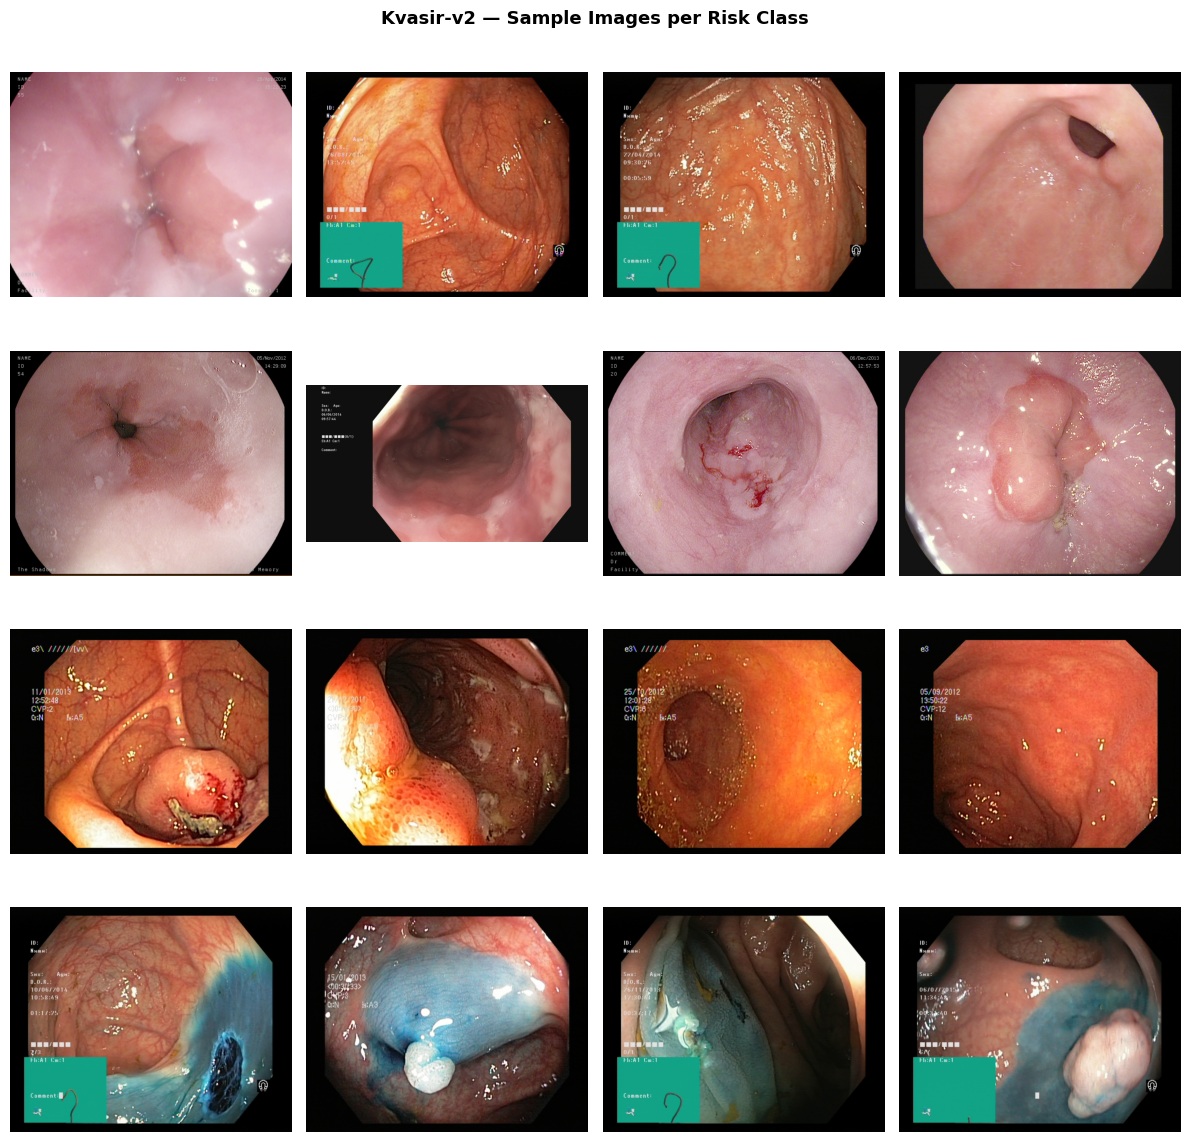

In [190]:
# Visualize Kvasir-v2 samples
visualize_dataset_samples('data/Kvasir-v2', KVASIR_V2_MAP, LABEL_NAMES,
                           n_per_class=4, title='Kvasir-v2')

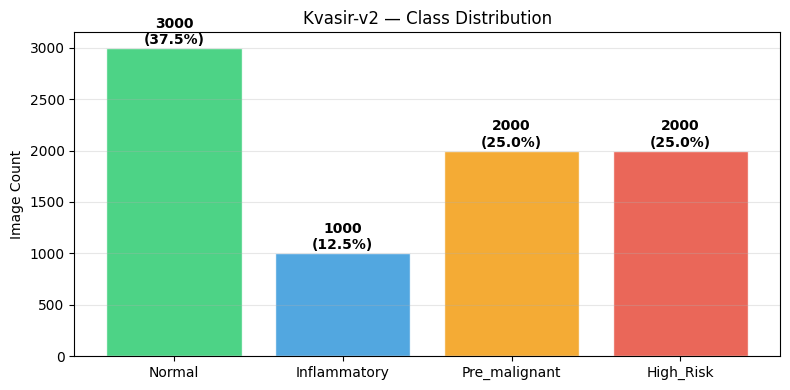

In [191]:
# Kvasir-v2 class distribution
plot_class_distribution('data/Kvasir-v2', KVASIR_V2_MAP, LABEL_NAMES,
                         title='Kvasir-v2 — Class Distribution')

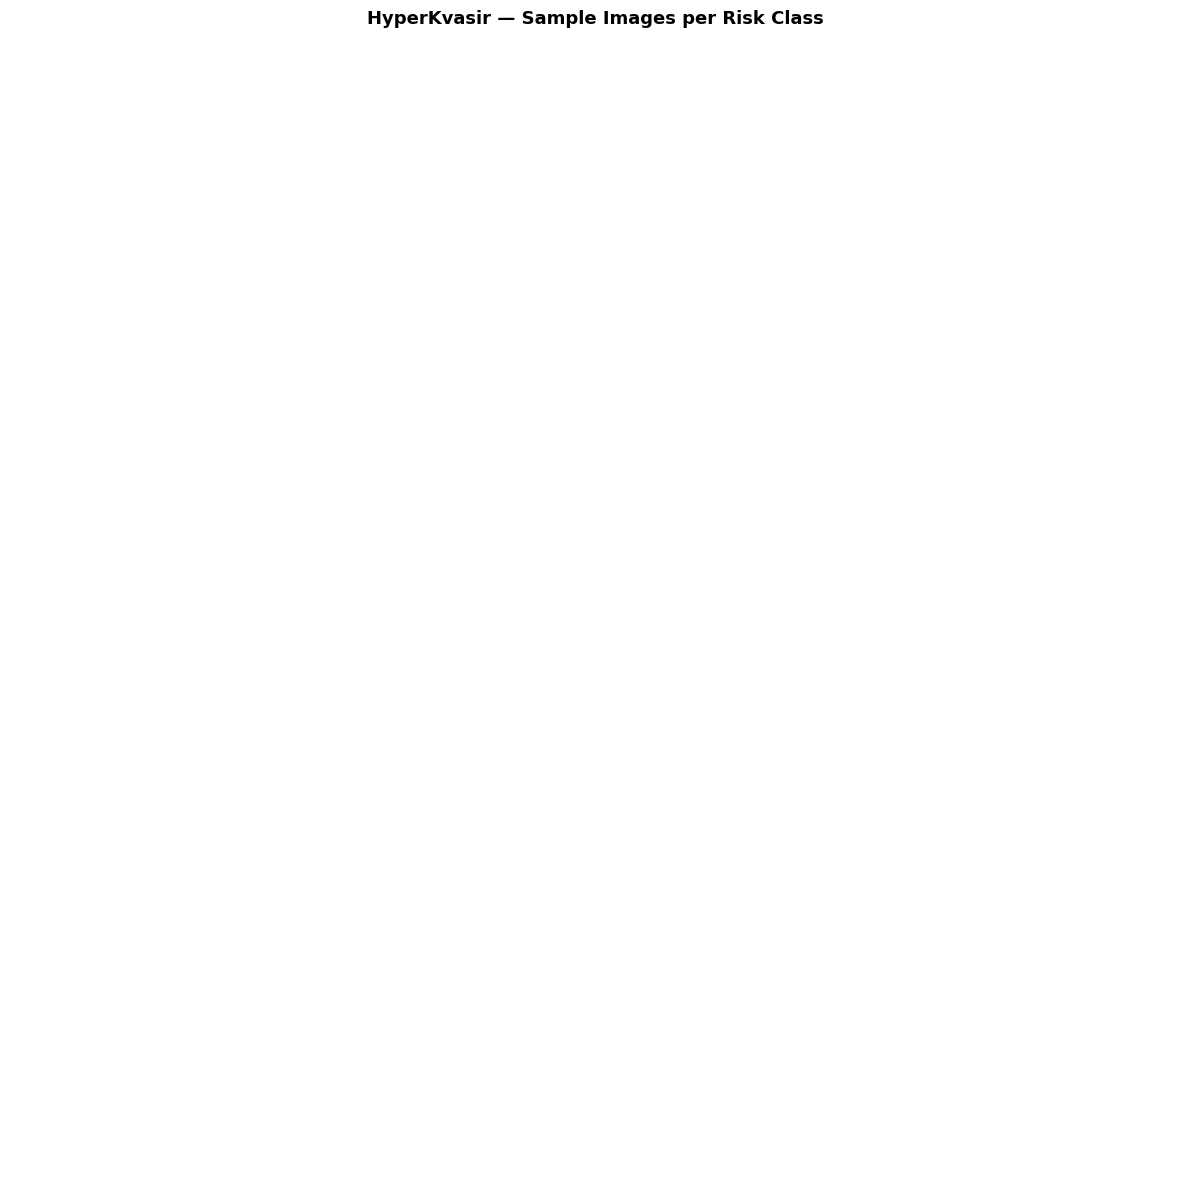

In [192]:
# Visualize HyperKvasir samples (run after extraction)
visualize_dataset_samples('data/HyperKvasir/labeled-images', HYPERKVASIR_MAP, LABEL_NAMES,
                           n_per_class=4, title='HyperKvasir')

In [193]:
# HyperKvasir class distribution (run after extraction)
plot_class_distribution('data/HyperKvasir/labeled-images', HYPERKVASIR_MAP, LABEL_NAMES,
                         title='HyperKvasir — Class Distribution')

[!] No images found in data/HyperKvasir/labeled-images


## 3. Data Augmentation & DataLoader

Preprocessing pipeline:
```
Image → CLAHE Enhancement → Resize → Augmentation → Normalize → Tensor
```

CLAHE (Contrast Limited Adaptive Histogram Equalization) enhances mucosal texture,
vascular patterns, and pit structures critical for risk-level discrimination.


In [195]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # Tolerate partially-extracted images

class CLAHETransform:
    """CLAHE on the L-channel of LAB space to enhance mucosal texture."""
    def __init__(self, clip_limit=CLAHE_CLIP_LIMIT, tile_grid_size=CLAHE_TILE_SIZE):
        self.clip_limit     = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, img):
        try:
            img_np = np.array(img.convert('RGB'))
            clahe  = cv2.createCLAHE(clipLimit=self.clip_limit,
                                      tileGridSize=self.tile_grid_size)
            lab        = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
            lab[..., 0] = clahe.apply(lab[..., 0])
            img_np     = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
            return Image.fromarray(img_np)
        except Exception as e:
            warnings.warn(f'CLAHETransform failed ({e}); returning original image.')
            return img


DATASET_MEAN = [0.485, 0.456, 0.406]
DATASET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD),
])

val_transforms = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD),
])

_BLANK = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))


class EndoscopyDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        missing = [p for p in self.df['image_path'] if not os.path.exists(p)]
        if missing:
            raise FileNotFoundError(f'{len(missing)} image paths not found. First: {missing[0]}')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['image_path']).convert('RGB')
        except Exception as e:
            warnings.warn(f"Bad image skipped: {e}")
            img = _BLANK.copy()
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(row['label'], dtype=torch.long)


def make_loaders(train_df, val_df, test_df):
    counts  = train_df['label'].value_counts().sort_index().values
    weights = 1.0 / counts
    sw      = torch.tensor(weights[train_df['label'].values], dtype=torch.float64)
    sampler = WeightedRandomSampler(
        sw, num_samples=len(sw), replacement=True,
        generator=torch.Generator().manual_seed(SEED)
    )
    pin = DEVICE.type == 'cuda'
    train_ldr = DataLoader(EndoscopyDataset(train_df, train_transforms),
                           BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=pin)
    val_ldr   = DataLoader(EndoscopyDataset(val_df,   val_transforms),
                           BATCH_SIZE, shuffle=False,  num_workers=0, pin_memory=pin)
    test_ldr  = DataLoader(EndoscopyDataset(test_df,  val_transforms),
                           BATCH_SIZE, shuffle=False,  num_workers=0, pin_memory=pin)
    return train_ldr, val_ldr, test_ldr


if len(df) > 0:
    train_ldr, val_ldr, test_ldr = make_loaders(train_df, val_df, test_df)
    print(f'DataLoaders ready: train={len(train_ldr)} batches  val={len(val_ldr)}  test={len(test_ldr)}')
    print('Pipeline: CLAHE -> Resize -> Augment -> Normalize')
    print('Truncated images: PIL loads with gray fill (LOAD_TRUNCATED_IMAGES=True)')


DataLoaders ready: train=167 batches  val=36  test=36
Pipeline: CLAHE → Resize → Augment → Normalize


## 4. Model Architecture — DenseNet-121 · EfficientNet-B4 · ViT-B/16 · Swin-T

First comprehensive CNN-vs-Transformer benchmark for gastrointestinal lesion risk stratification.

| Model | Type | Pre-training | Parameters |
|---|---|---|---|
| DenseNet-121 | CNN | ImageNet | 7M |
| EfficientNet-B4 | CNN | ImageNet | 19M |
| ViT-B/16 | Transformer | ImageNet-21k | 86M |
| Swin-T | Transformer | ImageNet-1k | 28M |


In [197]:
def build_densenet121(num_classes=NUM_CLASSES):
    m = models.densenet121(weights='DEFAULT')
    m.classifier = nn.Sequential(
        nn.Dropout(DROPOUT_RATES['densenet121']),
        nn.Linear(m.classifier.in_features, num_classes)
    )
    return m


def build_efficientnet_b4(num_classes=NUM_CLASSES):
    m = timm.create_model('efficientnet_b4', pretrained=True, num_classes=0)
    m.classifier = nn.Sequential(
        nn.Dropout(DROPOUT_RATES['efficientnet_b4']),
        nn.Linear(m.num_features, 256),
        nn.ReLU(),
        nn.Dropout(DROPOUT_RATES['efficientnet_b4'] / 2),
        nn.Linear(256, num_classes)
    )
    return m


def build_vit_b16(num_classes=NUM_CLASSES):
    m = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
    m.head = nn.Sequential(
        nn.Dropout(DROPOUT_RATES['vit_b16']),
        nn.Linear(m.num_features, num_classes)
    )
    return m


def build_swin_t(num_classes=NUM_CLASSES):
    m = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True,
                          num_classes=num_classes)
    in_features = m.head.fc.in_features
    m.head.fc = nn.Sequential(
        nn.Dropout(DROPOUT_RATES['swin_t']),
        nn.Linear(in_features, num_classes)
    )
    return m


MODEL_BUILDERS = {
    'densenet121':     build_densenet121,
    'efficientnet_b4': build_efficientnet_b4,
    'vit_b16':         build_vit_b16,
    'swin_t':          build_swin_t,
}

# Sanity-check: every model must output (B, NUM_CLASSES)
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
print(f'{"Model":<20} {"Type":<15} {"Params":>12}  {"Output Shape":<20}  Check')
print('-' * 75)
for name, builder in MODEL_BUILDERS.items():
    m    = builder()
    n    = sum(p.numel() for p in m.parameters())
    kind = 'Transformer' if name in ('vit_b16', 'swin_t') else 'CNN'
    out  = m(dummy)
    ok   = '✓' if list(out.shape) == [2, NUM_CLASSES] else f'✗ got {list(out.shape)}'
    print(f'{name:<20} {kind:<15} {n:>12,}  {str(list(out.shape)):<20}  {ok}')
    del m

Model                Type                  Params  Output Shape          Check
---------------------------------------------------------------------------
densenet121          CNN                6,957,956  [2, 4]                ✓
efficientnet_b4      CNN               18,008,652  [2, 4]                ✓
vit_b16              Transformer       85,801,732  [2, 4]                ✓
swin_t               Transformer       27,522,430  [2, 4]                ✓


## 5. Asymmetric Endoscopy Loss (AEL)

Missing a High-Risk lesion delays resection — survival drops from 90% to <20%.
AEL encodes this clinical cost asymmetry directly into the loss function.

| Class | Weight | Rationale |
|---|---|---|
| Normal (0) | 1.0 | Routine finding — misclassification is low cost |
| Inflammatory (1) | 2.0 | Missed inflammation delays medical treatment |
| Pre-malignant (2) | 3.0 | Missed biopsy allows unmonitored progression |
| High-Risk (3) | 5.0 | Missed intervention = preventable cancer death |


In [199]:
class AsymmetricEndoscopyLoss(nn.Module):
    """
    Weighted cross-entropy encoding ACG/ESGE clinical cost asymmetry.
    Weights are defined globally in AEL_WEIGHTS.
    """
    def __init__(self, weights=None):
        super().__init__()
        w = torch.tensor(weights if weights is not None else AEL_WEIGHTS,
                         dtype=torch.float32).to(DEVICE)
        self.ce = nn.CrossEntropyLoss(weight=w)

    def forward(self, logits, targets):
        return self.ce(logits, targets)


print('Asymmetric Endoscopy Loss (AEL):')
for i, (name, risk, w) in enumerate(zip(LABEL_NAMES, RISK_LABELS, AEL_WEIGHTS)):
    print(f'  Class {i} | {name:<20} weight={w}  →  {risk}')

Asymmetric Endoscopy Loss (AEL):
  Class 0 | Normal               weight=1.0  →  Routine Surveillance
  Class 1 | Inflammatory         weight=2.0  →  Medical Management
  Class 2 | Pre_malignant        weight=3.0  →  Biopsy + Surveillance
  Class 3 | High_Risk            weight=5.0  →  Immediate Intervention


## 6. Training with Transfer Learning

In [201]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, preds_all, trues_all = 0.0, [], []
    for imgs, labels in tqdm(loader, desc='  batches', leave=True):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        preds_all.extend(out.detach().argmax(1).cpu().numpy())
        trues_all.extend(labels.cpu().numpy())
    scheduler.step()
    return (total_loss / len(loader),
            f1_score(trues_all, preds_all, average='macro', zero_division=0))


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, preds_all, trues_all = 0.0, [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        total_loss += criterion(out, labels).item()
        preds_all.extend(out.argmax(1).cpu().numpy())
        trues_all.extend(labels.cpu().numpy())
    assert len(preds_all) == len(trues_all)
    return (f1_score(trues_all, preds_all, average='macro', zero_division=0),
            total_loss / len(loader), preds_all, trues_all)


def run_training(model, train_ldr, val_ldr, model_name,
                 epochs=25, lr=2e-4, ckpt_dir='checkpoints'):
    ckpt_path = os.path.join(ckpt_dir, model_name, 'best.pt')
    os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

    if os.path.exists(ckpt_path):
        print(f'[SKIP] Checkpoint found — loading {model_name}')
        model.load_state_dict(
            torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
        return model, {}

    model     = model.to(DEVICE)
    criterion = AsymmetricEndoscopyLoss()
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    best_f1, best_state = 0.0, None
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

    print(f'\n{"="*60}')
    print(f'  Training : {model_name}')
    print(f'  Device   : {DEVICE}  |  Epochs: {epochs}  |  LR: {lr}')
    print(f'  Loss     : AsymmetricEndoscopyLoss  weights={AEL_WEIGHTS}')
    print(f'{"="*60}')

    for epoch in range(1, epochs + 1):
        print(f'\nEpoch {epoch}/{epochs}')
        tl, tf = train_epoch(model, train_ldr, optimizer, scheduler, criterion, DEVICE)
        vf, vl, _, _ = evaluate(model, val_ldr, criterion, DEVICE)
        history['train_loss'].append(tl); history['val_loss'].append(vl)
        history['train_f1'].append(tf);  history['val_f1'].append(vf)
        marker = '  *** NEW BEST ***' if vf > best_f1 else ''
        print(f'  loss={tl:.4f}  train_F1={tf:.4f}  '
              f'val_loss={vl:.4f}  val_F1={vf:.4f}{marker}')
        if vf > best_f1:
            best_f1    = vf
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    torch.save(best_state, ckpt_path)
    print(f'\n  Done. Best val F1: {best_f1:.4f}  →  {ckpt_path}')
    return model, history


def plot_training_curves(histories: dict):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    colors = ['#2980B9', '#E74C3C', '#2ECC71', '#F39C12']
    for (name, h), color in zip(histories.items(), colors):
        if not h:
            continue
        axes[0].plot(h['train_loss'], '--', color=color, alpha=0.6, label=f'{name} train')
        axes[0].plot(h['val_loss'],   '-',  color=color, label=f'{name} val')
        axes[1].plot(h['train_f1'],   '--', color=color, alpha=0.6)
        axes[1].plot(h['val_f1'],     '-',  color=color, label=name)
    for ax, title, ylabel in zip(axes,
                                  ['AEL Loss Curves', 'Macro F1 Curves'],
                                  ['Loss', 'Macro F1']):
        ax.set(xlabel='Epoch', ylabel=ylabel, title=title)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    plt.suptitle('Training History — CNN vs Transformer (HyperKvasir)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Training functions defined.')

Training functions defined.


In [202]:
# ── RUN TRAINING (all 4 models) ───────────────────────────────────────────────
if 'train_ldr' not in globals():
    raise RuntimeError('Run Sections 2 & 3 first to load data and build DataLoaders.')

trained_models = {}
histories      = {}

trained_models['densenet121'],     histories['densenet121']     = run_training(build_densenet121(),     train_ldr, val_ldr, 'densenet121')
trained_models['efficientnet_b4'], histories['efficientnet_b4'] = run_training(build_efficientnet_b4(), train_ldr, val_ldr, 'efficientnet_b4')
trained_models['vit_b16'],         histories['vit_b16']         = run_training(build_vit_b16(),         train_ldr, val_ldr, 'vit_b16')
trained_models['swin_t'],          histories['swin_t']          = run_training(build_swin_t(),          train_ldr, val_ldr, 'swin_t')

print(f'\nAll {len(trained_models)} models trained.')
plot_training_curves(histories)


  Training : densenet121
  Device   : mps  |  Epochs: 25  |  LR: 0.0002
  Loss     : AsymmetricEndoscopyLoss  weights=[1.0, 2.0, 3.0, 5.0]

Epoch 1/25


  batches:  17%|█████▏                        | 29/167 [02:02<09:43,  4.23s/it]


OSError: Cannot load data/HyperKvasir/labeled-images/upper-gi-tract/anatomical-landmarks/retroflex-stomach/4f6c21be-28bc-4d6b-abc1-b1a0d7bd677d.jpg: image file is truncated (128 bytes not processed)

## 7. AEL Ablation Study
Compare Asymmetric Endoscopy Loss vs Cross-Entropy vs Focal Loss on DenseNet-121.

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


def run_ablation(train_ldr, val_ldr, test_ldr, epochs=10):
    loss_fns = {
        'Cross-Entropy':  nn.CrossEntropyLoss(),
        'Focal (γ=2)':    FocalLoss(gamma=2.0),
        'AEL (Ours)':     AsymmetricEndoscopyLoss(),
    }
    results = {}
    for name, loss_fn in loss_fns.items():
        print(f'\nAblation: {name}')
        model = build_densenet121().to(DEVICE)
        opt   = AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
        sch   = CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
        for _ in range(epochs):
            model.train()
            for imgs, labels in train_ldr:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                opt.zero_grad()
                loss_fn(model(imgs), labels).backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            sch.step()
        model.eval()
        preds_all, trues_all = [], []
        with torch.no_grad():
            for imgs, labels in test_ldr:
                preds_all.extend(model(imgs.to(DEVICE)).argmax(1).cpu().numpy())
                trues_all.extend(labels.numpy())
        macro_f1     = f1_score(trues_all, preds_all, average='macro', zero_division=0)
        high_risk_recall = recall_score(
            [1 if t == 3 else 0 for t in trues_all],
            [1 if p == 3 else 0 for p in preds_all], zero_division=0)
        results[name] = {'macro_f1': macro_f1, 'high_risk_recall': high_risk_recall}
        print(f'  Macro F1={macro_f1:.4f}  High-Risk Recall={high_risk_recall:.4f}')

    print('\nAblation Summary:')
    print(f'{"Loss":<20} {"Macro F1":>10} {"High-Risk Recall":>18}')
    print('-' * 50)
    for k, v in results.items():
        print(f'{k:<20} {v["macro_f1"]:>10.4f} {v["high_risk_recall"]:>18.4f}')
    return results


print('Ablation ready. Call: ablation_results = run_ablation(train_ldr, val_ldr, test_ldr)')


## 8. Cross-Dataset Evaluation — Kvasir-v2
Train on HyperKvasir, evaluate zero-shot on Kvasir-v2.
Kvasir-v2 folder structure: data/Kvasir-v2/<class-name>/<images>


In [ ]:
KVASIR_V2_MAP = {
    'esophagitis':        1,   # Inflammatory
    'ulcerative-colitis': 2,   # Pre-malignant (Kvasir-v2 has mixed severity)
    'polyps':             2,   # Pre-malignant
    'barretts':           2,   # Pre-malignant
    'normal-cecum':       0,
    'normal-pylorus':     0,
    'normal-z-line':      0,
    'dyed-lifted-polyps': 3,   # High-Risk
    'dyed-resection-margins': 3,
}


def load_kvasir_v2(data_dir: str) -> pd.DataFrame:
    rows = []
    if not os.path.exists(data_dir):
        print(f'[!] Kvasir-v2 not found at {data_dir}')
        print('    Download from: https://datasets.simula.no/kvasir/')
        return pd.DataFrame()
    for class_folder in os.listdir(data_dir):
        class_dir = os.path.join(data_dir, class_folder)
        if not os.path.isdir(class_dir): continue
        label = KVASIR_V2_MAP.get(class_folder)
        if label is None: continue
        for f in os.listdir(class_dir):
            if not f.lower().endswith(('.jpg', '.jpeg', '.png')): continue
            rows.append({'image_path': os.path.join(class_dir, f),
                         'label': label, 'label_name': LABEL_NAMES[label],
                         'source_class': class_folder})
    df = pd.DataFrame(rows)
    if len(df):
        print(f'Kvasir-v2: {len(df)} images')
        print(df['label_name'].value_counts().to_string())
    return df


@torch.no_grad()
def evaluate_detailed(model, loader, device, dataset_name=''):
    model.eval()
    preds_all, trues_all, probs_all = [], [], []
    for imgs, labels in loader:
        out = model(imgs.to(device))
        probs_all.extend(F.softmax(out, dim=1).cpu().numpy())
        preds_all.extend(out.argmax(1).cpu().numpy())
        trues_all.extend(labels.numpy())
    macro_f1     = f1_score(trues_all, preds_all, average='macro', zero_division=0)
    per_class    = f1_score(trues_all, preds_all, average=None,    zero_division=0)
    high_risk_recall = recall_score(
        [1 if t == 3 else 0 for t in trues_all],
        [1 if p == 3 else 0 for p in preds_all], zero_division=0)
    print(f'\n{"="*60}')
    print(f'Dataset: {dataset_name}  |  Macro F1: {macro_f1:.4f}  |  High-Risk Recall: {high_risk_recall:.4f}')
    print(classification_report(trues_all, preds_all, target_names=LABEL_NAMES, zero_division=0))
    return {'macro_f1': macro_f1, 'per_class': per_class,
            'high_risk_recall': high_risk_recall,
            'preds': preds_all, 'trues': trues_all,
            'probs': np.array(probs_all)}


def plot_confusion_matrix(results, model_name):
    cm = confusion_matrix(results['trues'], results['preds'])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    short = ['Normal', 'Inflam.', 'Pre-mal.', 'High-Risk']
    for ax, data, fmt, title in zip([ax1, ax2],
                                     [cm, cm.astype(float) / cm.sum(axis=1, keepdims=True)],
                                     ['d', '.1%'],
                                     ['Count', 'Normalized']):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                    xticklabels=short, yticklabels=short)
        ax.set(xlabel='Predicted', ylabel='True',
               title=f'{model_name} Confusion Matrix ({title})')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()


print('Cross-dataset evaluation ready.')


In [ ]:
# ── RUN EVALUATION (test set + Kvasir-v2) ────────────────────────────────────
criterion  = AsymmetricEndoscopyLoss()
results    = {}

for name, model in trained_models.items():
    print(f'\n--- {name} ---')
    results[name] = evaluate_detailed(model, test_ldr, DEVICE, dataset_name=f'{name} (HyperKvasir test)')
    plot_confusion_matrix(results[name], name)

# Cross-dataset on Kvasir-v2
kv2_df = load_kvasir_v2('data/Kvasir-v2')
ext_results = {}
if len(kv2_df) > 0:
    kv2_ldr = DataLoader(EndoscopyDataset(kv2_df, val_transforms),
                         BATCH_SIZE, shuffle=False, num_workers=0)
    ext_results['Kvasir-v2'] = {}
    for name, model in trained_models.items():
        print(f'\n--- {name} on Kvasir-v2 ---')
        ext_results['Kvasir-v2'][name] = evaluate_detailed(model, kv2_ldr, DEVICE,
                                                            dataset_name=f'{name} (Kvasir-v2)')

plot_roc_curves(results)
print_auc_table(results)
print_paper_tables(results, ext_results)

## 9. ROC-AUC Curves — Per Class (One-vs-Rest)

In [ ]:
def plot_roc_curves(results_dict: dict):
    n_cls   = NUM_CLASSES
    colors  = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C']
    styles  = ['-', '--', ':', '-.']
    fig, axes = plt.subplots(1, n_cls, figsize=(5 * n_cls, 5))

    for c, (cls_name, risk, ax) in enumerate(zip(LABEL_NAMES, RISK_LABELS, axes)):
        for (model_name, results), ls in zip(results_dict.items(), styles):
            trues_bin = [1 if t == c else 0 for t in results['trues']]
            probs_cls = np.array(results['probs'])[:, c]
            fpr, tpr, _ = roc_curve(trues_bin, probs_cls)
            roc_auc     = auc(fpr, tpr)
            ax.plot(fpr, tpr, linestyle=ls, linewidth=2,
                    label=f'{model_name} (AUC={roc_auc:.3f})')
        ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
        ax.set(xlabel='FPR', ylabel='TPR',
               title=f'{cls_name}\n({risk})')
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
        if c == 3:
            ax.text(0.3, 0.05, 'HIGH PRIORITY\nImmediate Intervention',
                    fontsize=8, color='red', alpha=0.8,
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.suptitle('Per-Class ROC Curves — GI Lesion Risk Stratification (One-vs-Rest)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


def print_auc_table(results_dict: dict):
    print(f'\n{"Model":<22}', end='')
    for c in LABEL_NAMES: print(f'{c:>16}', end='')
    print(f'{"Macro AUC":>12}')
    print('-' * 90)
    for model_name, results in results_dict.items():
        trues_bin = label_binarize(results['trues'], classes=list(range(NUM_CLASSES)))
        aucs = []
        print(f'{model_name:<22}', end='')
        for c in range(NUM_CLASSES):
            a = roc_auc_score(trues_bin[:, c], np.array(results['probs'])[:, c])
            aucs.append(a)
            print(f'{a:>16.4f}', end='')
        print(f'{np.mean(aucs):>12.4f}')


print('ROC-AUC analysis ready.')


## 10. GradCAM Explainability
Localizes mucosal irregularities, pit patterns, and vascular changes
that drive each risk-tier classification decision.


In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.grads = None
        self.acts  = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'acts', o.detach()))
        # register_full_backward_hook is the non-deprecated API (PyTorch ≥ 2.0)
        target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'grads', go[0].detach()))

    def generate(self, img_tensor, class_idx=None):
        self.model.eval()
        img = img_tensor.unsqueeze(0).to(DEVICE)
        out = self.model(img)
        if class_idx is None:
            class_idx = out.argmax().item()
        self.model.zero_grad()
        out[0, class_idx].backward()

        if self.grads.dim() == 4:
            # CNN: (B, C, H, W)
            weights = self.grads.mean(dim=[2, 3], keepdim=True)
            cam     = F.relu((weights * self.acts).sum(1, keepdim=True))
            cam     = cam.squeeze().cpu().numpy()
        else:
            # Transformer: (B, N, C) — reshape token sequence to 2-D spatial grid
            weights = self.grads.mean(dim=1)                              # (B, C)
            cam     = F.relu((weights.unsqueeze(1) * self.acts).sum(-1))  # (B, N)
            cam     = cam.squeeze().cpu().numpy()
            n       = int(cam.shape[0] ** 0.5)
            cam     = cam[:n * n].reshape(n, n)

        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        return cam, class_idx


def get_target_layer(model, model_name):
    if model_name == 'densenet121':
        return model.features.denseblock4.denselayer16.conv2
    elif model_name == 'efficientnet_b4':
        return model.blocks[-1][-1].conv_pwl
    elif model_name == 'vit_b16':
        return model.blocks[-1].norm1
    elif model_name == 'swin_t':
        return model.layers[-1].blocks[-1].norm1
    raise ValueError(f'Unknown model: {model_name}')


def visualize_gradcam(model, model_name, image_paths, true_labels=None):
    target_layer = get_target_layer(model, model_name)
    gcam = GradCAM(model, target_layer)
    inv  = transforms.Normalize(
        mean=[-m / s for m, s in zip(DATASET_MEAN, DATASET_STD)],
        std=[1 / s for s in DATASET_STD])

    n      = len(image_paths)
    colors = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C']
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 9))
    axes = axes.reshape(2, n)   # always 2-D, regardless of n

    for i, path in enumerate(image_paths):
        img_t     = val_transforms(Image.open(path).convert('RGB'))
        cam, pred = gcam.generate(img_t)
        img_np    = np.array(inv(img_t).permute(1, 2, 0).clamp(0, 1))
        heatmap   = cv2.cvtColor(
            cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET),
            cv2.COLOR_BGR2RGB) / 255.0
        overlay   = np.clip(0.6 * img_np + 0.4 * heatmap, 0, 1)

        gt = LABEL_NAMES[true_labels[i]] if true_labels else ''
        axes[0, i].imshow(img_np);  axes[0, i].set_title(f'GT: {gt}', fontsize=10)
        axes[1, i].imshow(overlay); axes[1, i].set_title(
            f'{LABEL_NAMES[pred]}\n{RISK_LABELS[pred]}',
            fontsize=9, color=colors[pred])
        for ax in [axes[0, i], axes[1, i]]:
            ax.axis('off')

    plt.suptitle(f'GradCAM — {model_name}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'gradcam_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('GradCAM ready.')

## 11. Monte Carlo Dropout Uncertainty
Flags borderline lesions for mandatory endoscopist review.

In [ ]:
def mc_predict(model, img_tensor, n_samples=30):
    """Monte Carlo Dropout inference. Runs n_samples stochastic forward passes."""
    model.eval()
    # Enable only Dropout layers for MC sampling
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

    img   = img_tensor.unsqueeze(0).to(DEVICE)
    probs = []
    with torch.no_grad():
        for _ in range(n_samples):
            probs.append(F.softmax(model(img), dim=1).cpu().numpy())

    # Restore full eval mode
    model.eval()

    probs      = np.stack(probs).squeeze(1)          # (n_samples, NUM_CLASSES)
    mean_probs = probs.mean(axis=0)
    pred       = int(mean_probs.argmax())
    confidence = float(mean_probs.max())
    entropy    = float(-np.sum(mean_probs * np.log(mean_probs + 1e-8)))
    flag       = confidence < 0.75 or pred >= 2      # Pre-malignant or High-Risk always flagged

    return {
        'prediction':  pred,
        'label':       LABEL_NAMES[pred],
        'risk':        RISK_LABELS[pred],
        'confidence':  confidence,
        'uncertainty': entropy,
        'flag':        flag,
        'mean_probs':  mean_probs,
    }


print('MC Dropout ready.')
print('Flag rule: confidence < 0.75  OR  predicted class ≥ Pre-malignant')

## 12. Endoscopist Workload Simulation
Quantifies AI burden reduction while maintaining zero missed High-Risk lesions.

In [ ]:
def endoscopist_simulation(model, test_df, confidence_threshold=0.75):
    auto_cleared, flagged = 0, 0
    missed_high_risk = 0
    flag_breakdown = {'low_confidence': 0, 'pre_malignant': 0, 'high_risk': 0}

    # Run mc_predict once per image and store results
    mc_results = []
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Simulating'):
        img = val_transforms(Image.open(row['image_path']).convert('RGB'))
        res = mc_predict(model, img)
        mc_results.append((res, row['label']))

    for res, true_label in mc_results:
        if res['flag']:
            flagged += 1
            if res['confidence'] < confidence_threshold: flag_breakdown['low_confidence'] += 1
            if res['prediction'] == 2:                   flag_breakdown['pre_malignant']  += 1
            if res['prediction'] == 3:                   flag_breakdown['high_risk']       += 1
        else:
            auto_cleared += 1
            if true_label == 3:
                missed_high_risk += 1

    total = len(test_df)
    print(f'\nEndoscopist Workload Simulation')
    print(f'  Total patients:              {total}')
    print(f'  AI auto-cleared:             {auto_cleared} ({100*auto_cleared/total:.1f}%)')
    print(f'  Flagged for endoscopist:     {flagged} ({100*flagged/total:.1f}%)')
    print(f'  Workload reduction:          {100*auto_cleared/total:.1f}%')
    print(f'  Missed High-Risk lesions:    {missed_high_risk}  (target: 0)')
    print(f'  Flag breakdown: {flag_breakdown}')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
    ax1.pie([auto_cleared, flagged],
            labels=[f'AI auto-cleared\n({100*auto_cleared/total:.1f}%)',
                    f'Endoscopist review\n({100*flagged/total:.1f}%)'],
            colors=['#2ECC71', '#E74C3C'], autopct='%1.1f%%', startangle=90)
    ax1.set_title('Endoscopy Screening Workflow\nAI Workload Distribution')

    # Threshold sweep reuses precomputed mc_results — no redundant forward passes
    thresholds = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
    reductions = []
    for thresh in thresholds:
        cleared = sum(1 for res, _ in mc_results
                      if res['confidence'] >= thresh and res['prediction'] < 2)
        reductions.append(100 * cleared / total)
    ax2.plot(thresholds, reductions, 'b-o', linewidth=2)
    ax2.axvline(confidence_threshold, color='red', linestyle='--',
                label=f'Selected threshold={confidence_threshold}')
    ax2.set(xlabel='Confidence Threshold', ylabel='Workload Reduction (%)',
            title='Threshold vs. Endoscopist Burden Reduction')
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('workload_simulation.png', dpi=150, bbox_inches='tight')
    plt.show()
    return auto_cleared, flagged, missed_high_risk


print('Simulation ready.')

## 13. Cross-Demographic Equity (CD-CTEI)
Equity analysis across age and sex subgroups.

In [ ]:
def compute_cdctei(f1_dict: dict) -> float:
    vals = np.array(list(f1_dict.values()))
    mu, sigma = vals.mean(), vals.std()
    return float(1 - sigma / mu) if mu > 0 else 0.0


def equity_analysis(model, test_df, device, group_col='age_group'):
    if group_col not in test_df.columns:
        print(f'Add {group_col} column to test_df for equity analysis.')
        print('Example groups: age_group=[<40, 40-60, >60]  sex=[M, F]')
        return

    criterion = AsymmetricEndoscopyLoss()
    results   = {}
    for group in sorted(test_df[group_col].unique()):
        sub = test_df[test_df[group_col] == group].reset_index(drop=True)
        ldr = DataLoader(EndoscopyDataset(sub, val_transforms), BATCH_SIZE, shuffle=False)
        f1, _, _, _ = evaluate(model, ldr, criterion, device)
        results[str(group)] = f1

    ctei = compute_cdctei(results)
    print(f'\nCD-CTEI: {ctei:.4f}  (threshold ≥ 0.95)')
    print(f'{"Group":<20} {"Macro F1":>10}')
    print('-' * 32)
    for g, f in sorted(results.items(), key=lambda x: x[1]):
        flag = '⚠' if f < 0.85 else '✓'
        print(f'{g:<20} {f:>10.4f}  {flag}')

    fig, ax = plt.subplots(figsize=(9, 4))
    groups = list(results.keys()); f1s = [results[g] for g in groups]
    ax.bar(groups, f1s,
           color=['#2980B9' if f >= 0.85 else '#E74C3C' for f in f1s], alpha=0.85)
    ax.axhline(0.85, color='red', linestyle='--', label='Min acceptable threshold')
    ax.set(ylabel='Macro F1',
           title=f'CD-CTEI={ctei:.3f} — Per-Demographic Stratification Performance')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=15); plt.tight_layout()
    plt.savefig('cdctei_equity.png', dpi=150, bbox_inches='tight')
    plt.show()
    return results, ctei


print('CD-CTEI equity analysis ready.')


## 14. Results Summary & Paper Tables

In [ ]:
def print_paper_tables(results_dict: dict, ext_results: dict = None):
    print('\nTable 2. Per-Class F1 Score — All Models')
    print('=' * 95)
    print(f'{"Class":<22}', end='')
    for name in results_dict: print(f'{name:>18}', end='')
    print(f'  Clinical Action')
    print('-' * 95)
    for i, (label, action) in enumerate(zip(LABEL_NAMES, RISK_ACTIONS)):
        print(f'{label:<22}', end='')
        for res in results_dict.values():
            print(f'{res["per_class"][i]:>18.4f}', end='')
        print(f'  {action}')
    print('-' * 95)
    print(f'{"Macro F1":<22}', end='')
    for res in results_dict.values(): print(f'{res["macro_f1"]:>18.4f}', end='')
    print()
    print(f'{"High-Risk Recall":<22}', end='')
    for res in results_dict.values(): print(f'{res["high_risk_recall"]:>18.4f}', end='')
    print()

    if ext_results:
        print('\nTable 3. Cross-Dataset Generalization (Kvasir-v2)')
        print('=' * 70)
        print(f'{"Dataset":<20}', end='')
        for name in results_dict: print(f'{name:>18}', end='')
        print()
        print('-' * 70)
        for site, res_by_model in ext_results.items():
            print(f'{site:<20}', end='')
            for name in results_dict:
                print(f'{res_by_model.get(name, {}).get("macro_f1", 0):>18.4f}', end='')
            print()


print('Results functions ready.')


## Summary

| Component | Detail |
|---|---|
| **Task** | 4-class GI lesion risk stratification (ACG/ESGE guideline-aligned) |
| **Models** | DenseNet-121 · EfficientNet-B4 · ViT-B/16 · Swin-T |
| **Loss** | Asymmetric Endoscopy Loss (AEL) — High-Risk weight=5× |
| **Training set** | HyperKvasir (110,079 images, 23 classes → 4 risk tiers) |
| **External validation** | Kvasir-v2 (8,000 images) |
| **Explainability** | GradCAM — mucosal/vascular feature localization per risk class |
| **Uncertainty** | MC Dropout — flags Pre-malignant/High-Risk for endoscopist review |
| **Ablation** | AEL vs Cross-Entropy vs Focal Loss |
| **ROC-AUC** | Per-class one-vs-rest curves for all four models |
| **Fairness** | CD-CTEI across age and sex demographic subgroups |
| **Benchmark** | First CNN-vs-Transformer comparison for 4-class GI risk stratification |

### Output Files
- `training_curves.png`
- `confusion_matrix_<model>.png`
- `roc_curves.png`
- `gradcam_<model>.png`
- `workload_simulation.png`
- `cdctei_equity.png`
- `checkpoints/<model>/best.pt`
